# Exploração de Plots Bayesianos (baycomp e baycomp_plotting)

Este notebook explora o uso dos pacotes `baycomp` e `baycomp_plotting`.

**Nota sobre os testes e plots:**
- `bplt.dens()` → requer um posterior de `CorrelatedTTest` (que tem `.rope`, `.df`, `.mean`, `.var`)
- `bplt.tern()` → requer um posterior de `SignedRankTest` ou `HierarchicalTest` (que tem `.probs()`, `.sample`)

**Cores disponíveis em `bplt.Color`:** `BLUE`, `GREEN`, `BORDEAUX`, `GRAY`

**Nota sobre os dados fictícios:**
No notebook do Heatmap, os dados fictícios foram criados já como as probabilidades finais (`p_esquerda`, `p_rope`, `p_direita`). No entanto, o `baycomp_plotting` desenha as distribuições *posteriori* completas no simplex. Por isso, precisamos criar os "scores crus" (raw scores) simulados para que o `baycomp` construa as distribuições, cujas médias resultarão em classificações similares (Equivalente, Superior, Incerto).

In [14]:
# 1. Instalação e Importação
!pip install baycomp baycomp_plotting

import numpy as np
import baycomp
import baycomp_plotting as bplt
import matplotlib.pyplot as plt

/bin/bash: /home/luiz/miniconda3/envs/treina/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [15]:
# 2. Geração de scores fictícios (Ex: 10 datasets/folds)
np.random.seed(42)

# Simulando de forma que os resultados se assemelhem ao Heatmap:
# GPT-4 vs Claude-3 -> Equivalente (médias e variâncias muito próximas)
gpt4_scores = np.random.normal(0.85, 0.02, 10)
claude3_scores = np.random.normal(0.85, 0.02, 10)

# GPT-4 vs Llama-3 -> GPT-4 Superior (Llama-3 tem média menor)
llama3_scores = np.random.normal(0.79, 0.03, 10)

print("Média GPT-4:", gpt4_scores.mean())
print("Média Claude-3:", claude3_scores.mean())
print("Média Llama-3:", llama3_scores.mean())

Média GPT-4: 0.8589612222339751
Média Claude-3: 0.8341868353083516
Média Llama-3: 0.7833446930599164


## Comparação 1: GPT-4 vs Claude-3 (Equivalentes)

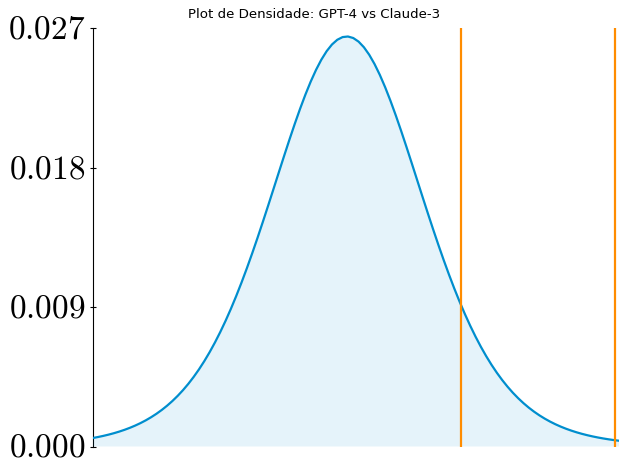

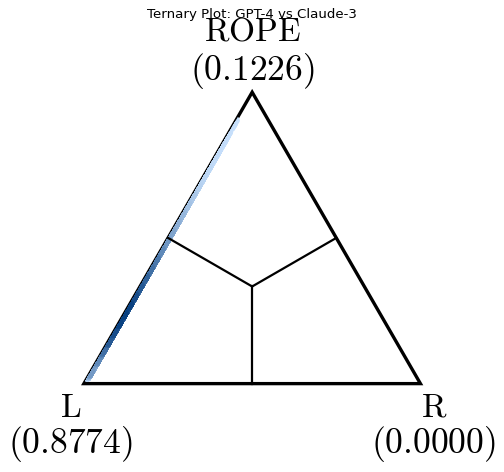

In [16]:
# CorrelatedTTest para o plot de densidade (requer .rope, .df, .mean, .var)
ct_gpt4_claude3 = baycomp.CorrelatedTTest(gpt4_scores, claude3_scores, rope=0.01)
# SignedRankTest para o ternary plot (requer .probs(), .sample)
sr_gpt4_claude3 = baycomp.SignedRankTest(gpt4_scores, claude3_scores, rope=0.01)

fig_dens = bplt.dens(ct_gpt4_claude3, label="GPT-4 vs Claude-3", color=bplt.Color.BLUE)
fig_dens.suptitle("Plot de Densidade: GPT-4 vs Claude-3")
plt.show()

fig_tern = bplt.tern(sr_gpt4_claude3)
fig_tern.suptitle("Ternary Plot: GPT-4 vs Claude-3")
plt.show()

## Comparação 2: GPT-4 vs Llama-3 (Superior)

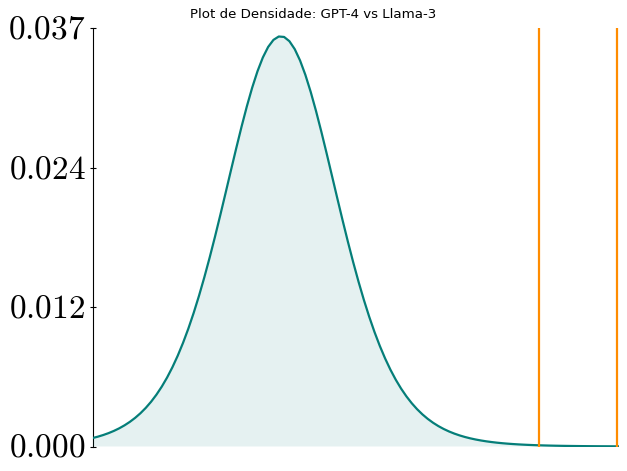

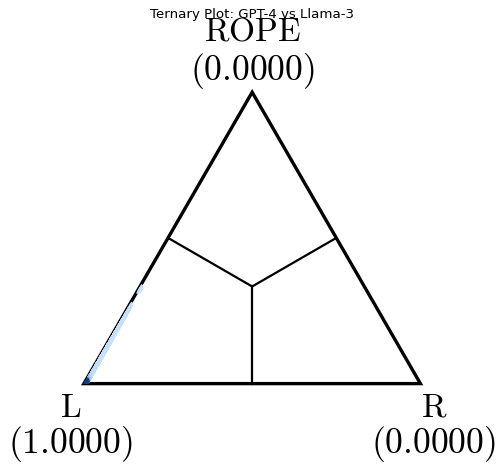

In [17]:
ct_gpt4_llama3 = baycomp.CorrelatedTTest(gpt4_scores, llama3_scores, rope=0.01)
sr_gpt4_llama3 = baycomp.SignedRankTest(gpt4_scores, llama3_scores, rope=0.01)

fig_dens = bplt.dens(ct_gpt4_llama3, label="GPT-4 vs Llama-3", color=bplt.Color.GREEN)
fig_dens.suptitle("Plot de Densidade: GPT-4 vs Llama-3")
plt.show()

fig_tern = bplt.tern(sr_gpt4_llama3)
fig_tern.suptitle("Ternary Plot: GPT-4 vs Llama-3")
plt.show()

## Comparação 3: Claude-3 vs Llama-3

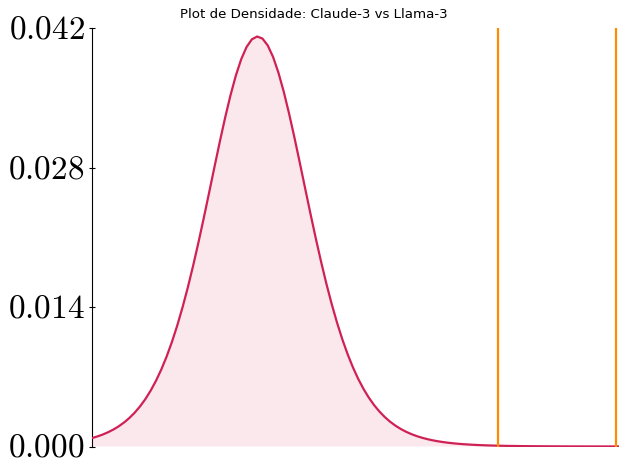

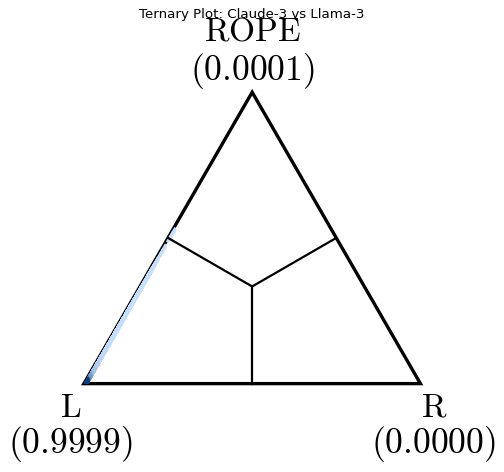

In [18]:
ct_claude3_llama3 = baycomp.CorrelatedTTest(claude3_scores, llama3_scores, rope=0.01)
sr_claude3_llama3 = baycomp.SignedRankTest(claude3_scores, llama3_scores, rope=0.01)

fig_dens = bplt.dens(ct_claude3_llama3, label="Claude-3 vs Llama-3", color=bplt.Color.BORDEAUX)
fig_dens.suptitle("Plot de Densidade: Claude-3 vs Llama-3")
plt.show()

fig_tern = bplt.tern(sr_claude3_llama3)
fig_tern.suptitle("Ternary Plot: Claude-3 vs Llama-3")
plt.show()